In [106]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Load the merged dataset
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_final_norm.csv')

# Convert 'state' if needed
state_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9}
df['state'] = df['state'].map(state_map)

# 🔍 Check which columns you’re using
feature_cols = [col for col in df.columns if col not in ['SOH', 'capacity', 'cycle', 'cell', 'T_C','state', 'Zmag_1000Hz','R_sei', 'R_s','Zmag_100Hz','C_dl_est','Zmag_0.1Hz','Zmag_10Hz','R_ct','tail_slope','tail_angle_deg','f_peak_main','Phase_100Hz', 'Phase_0.1Hz','Phase_1000Hz','Phase_10Hz']]  # Adjust as needed
target_col = 'SOH'

In [107]:

# -------- EXPLICIT TRAIN + TEST DEFINITIONS --------

test_groups = [
    (45, 1),
    (25, 1),
    (35, 2)
]

train_groups = [
    
    (25, 2),
    (25, 3),
    (25, 4),
    (25, 5),
    (25, 6),
    (25, 7),
    (25, 8),
    (45, 2),
    (35, 1)
]

test_mask = df.apply(
    lambda row: (row["T_C"], row["cell"]) in test_groups,
    axis=1
)

train_mask = df.apply(
    lambda row: (row["T_C"], row["cell"]) in train_groups,
    axis=1
)

test_df  = df[test_mask]
train_df = df[train_mask]

print("Train samples:", train_df.shape)
print("Test samples :", test_df.shape)

print("\nUnique test conditions:")
print(test_df[["T_C", "cell"]].drop_duplicates())

print("\nOverlap check:", 
      set(zip(train_df.T_C, train_df.cell)) &
      set(zip(test_df.T_C, test_df.cell)))




Train samples: (1719, 29)
Test samples : (878, 29)

Unique test conditions:
      T_C  cell
0      25     1
1670   35     2
1988   45     1

Overlap check: set()


In [108]:
X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test   = test_df[feature_cols], test_df[target_col]

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

In [109]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---- Predict ----
y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

# ---- Metrics ----
r2_train  = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_test  = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("🔍 Training Performance:")
print(f"  R²   : {r2_train:.4f}")
print(f"  MAE  : {mae_train:.4f}")
print(f"  RMSE : {rmse_train:.4f}")

print("\n🧪 Test Performance:")
print(f"  R²   : {r2_test:.4f}")
print(f"  MAE  : {mae_test:.4f}")
print(f"  RMSE : {rmse_test:.4f}")

# ---- Show test groups used ----
if {"T_C", "cell"}.issubset(test_df.columns):
    test_groups_used = (
        test_df[["T_C", "cell"]]
        .drop_duplicates()
        .sort_values(["T_C", "cell"])
        .reset_index(drop=True)
    )
    print("\n🧾 Test (T_C, cell) groups used:")
    print(test_groups_used.to_string(index=False))
else:
    print("\n⚠️ Could not list test groups (missing 'T_C' or 'cell' in test_df).")


🔍 Training Performance:
  R²   : 0.9984
  MAE  : 0.0025
  RMSE : 0.0054

🧪 Test Performance:
  R²   : 0.7799
  MAE  : 0.0463
  RMSE : 0.0557

🧾 Test (T_C, cell) groups used:
 T_C  cell
  25     1
  35     2
  45     1


In [110]:
if {"T_C", "cell"}.issubset(test_df.columns):
    test_eval = test_df.copy()
    test_eval = test_eval.reset_index(drop=True)
    test_eval["SOH_true"] = y_test.reset_index(drop=True) if hasattr(y_test, "reset_index") else y_test
    test_eval["SOH_pred"] = y_test_pred

    rows = []
    for (t, c), g in test_eval.groupby(["T_C", "cell"]):
        r2  = r2_score(g["SOH_true"], g["SOH_pred"]) if len(g) >= 2 else np.nan
        mae = mean_absolute_error(g["SOH_true"], g["SOH_pred"])
        rmse = np.sqrt(mean_squared_error(g["SOH_true"], g["SOH_pred"]))
        rows.append({"T_C": t, "cell": c, "n": len(g), "R2": r2, "MAE": mae, "RMSE": rmse})

    per_cell_metrics = (
        pd.DataFrame(rows)
        .sort_values(["T_C", "cell"])
        .reset_index(drop=True)
    )

    print("\n📌 Test metrics per (T_C, cell):")
    print(per_cell_metrics.to_string(index=False))



📌 Test metrics per (T_C, cell):
 T_C  cell   n       R2      MAE     RMSE
  25     1 261 0.822075 0.062266 0.070662
  35     2 318 0.656021 0.038882 0.042909
  45     1 299 0.388291 0.040152 0.052967


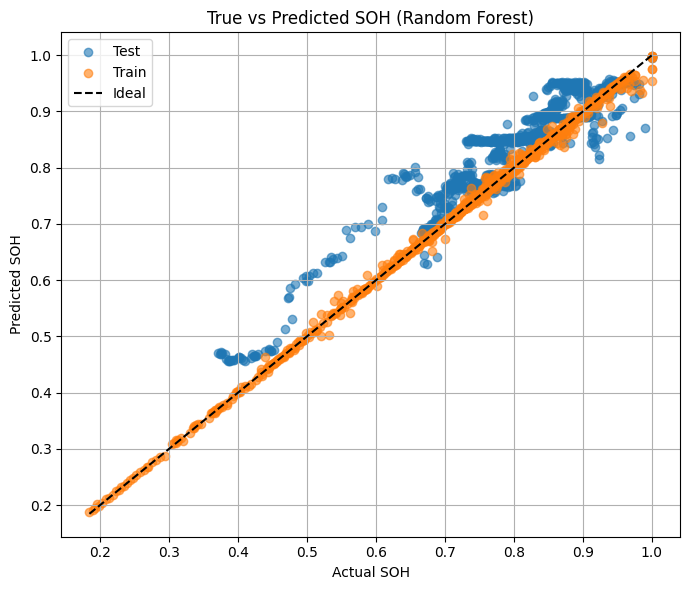

In [111]:
import matplotlib.pyplot as plt
import pandas as pd

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

# Create plotting DataFrames
train_plot = pd.DataFrame({
    "SOH_true": y_train,
    "SOH_pred": y_train_pred,
    "set": "Train"
})

test_plot = pd.DataFrame({
    "SOH_true": y_test,
    "SOH_pred": y_test_pred,
    "set": "Test"
})

plot_df = pd.concat([train_plot, test_plot])

# Diagonal limits
min_val = min(plot_df["SOH_true"].min(), plot_df["SOH_pred"].min())
max_val = max(plot_df["SOH_true"].max(), plot_df["SOH_pred"].max())

# Plot
plt.figure(figsize=(7,6))
for s, df_s in plot_df.groupby("set"):
    plt.scatter(
        df_s["SOH_true"],
        df_s["SOH_pred"],
        label=s,
        alpha=0.6
    )

plt.plot([min_val, max_val], [min_val, max_val], "k--", label="Ideal")
plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("True vs Predicted SOH (Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


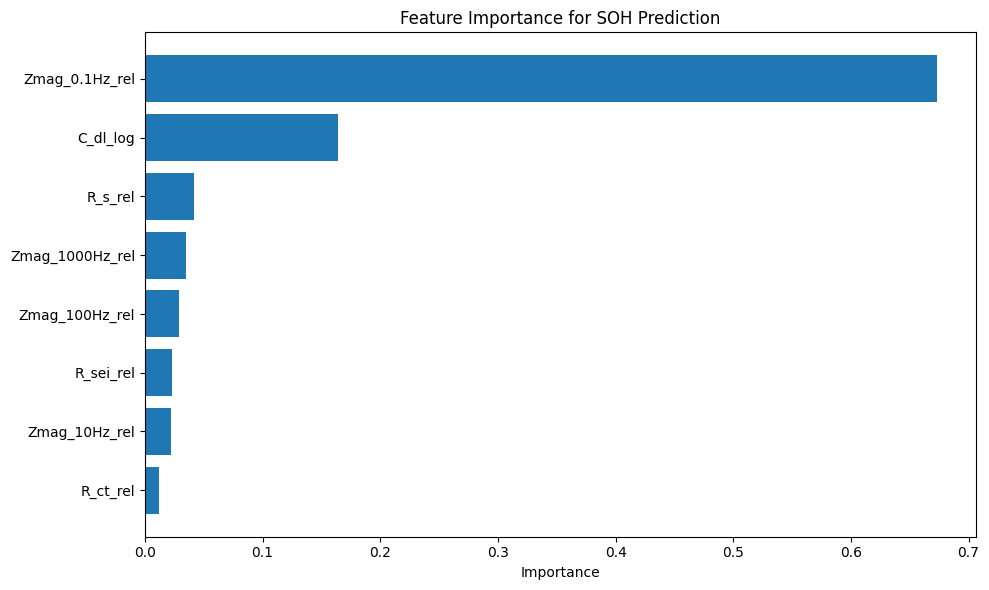

In [112]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance for SOH Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
